# 🩺 نظام ذكي للتنبؤ بخطر الإصابة بالسكري
## Diabetes Risk Prediction using RBF Neural Network + Explainable AI

---
| | |
|---|---|
| **Dataset** | Pima Indians Diabetes Dataset (768 records) |
| **Model** | Radial Basis Function (RBF) Network – Built from Scratch |
| **Explainability** | GROQ API – LLaMA 3.3 70B |
| **Interface** | Gradio Blocks |

### 📋 Pipeline:
1. Install & Import Libraries
2. Load & Explore Data
3. Data Preprocessing (Zeros → Median, Scaling, SMOTE)
4. Exploratory Visualizations
5. K-Means + Elbow Method (RBF Centers)
6. RBF Network – Manual Implementation
7. Threshold Optimization (F1-Score)
8. Evaluation & Visualizations
9. GROQ AI Integration
10. Gradio Web Interface


## 📦 Step 1 – Install Libraries

In [4]:
!pip install imbalanced-learn groq gradio scikit-learn matplotlib seaborn -q
print("✅ All libraries installed")


✅ All libraries installed


## 📚 Step 2 – Import Libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                             f1_score, classification_report, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
from groq import Groq
import gradio as gr

# ── Dark Theme ──────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0f172a',
    'axes.facecolor':    '#1e293b',
    'axes.edgecolor':    '#475569',
    'text.color':        'white',
    'axes.labelcolor':   'white',
    'xtick.color':       'white',
    'ytick.color':       'white',
    'grid.color':        '#334155',
    'grid.linestyle':    '--',
    'grid.alpha':        0.4,
})

print("✅ Imports done")


✅ Imports done


## 📥 Step 3 – Load & Explore Data

In [6]:
# ── Load ──────────────────────────────────────
df = pd.read_csv('D:\\naf\\359611_6a0b3f1a6fb0b_1779121946.csv')
df_raw = df.copy()

print(f"Shape  : {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(10)


Shape  : (768, 9)
Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [7]:
print("📊 Statistical Summary:")
df.describe().T.style.background_gradient(cmap='Blues')


📊 Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.000000,3.845052,3.369578,0.000000,1.000000,3.000000,6.000000,17.000000
Glucose,768.000000,120.894531,31.972618,0.000000,99.000000,117.000000,140.250000,199.000000
BloodPressure,768.000000,69.105469,19.355807,0.000000,62.000000,72.000000,80.000000,122.000000
SkinThickness,768.000000,20.536458,15.952218,0.000000,0.000000,23.000000,32.000000,99.000000
Insulin,768.000000,79.799479,115.244002,0.000000,0.000000,30.500000,127.250000,846.000000
BMI,768.000000,31.992578,7.884160,0.000000,27.300000,32.000000,36.600000,67.100000
DiabetesPedigreeFunction,768.000000,0.471876,0.331329,0.078000,0.243750,0.372500,0.626250,2.420000
Age,768.000000,33.240885,11.760232,21.000000,24.000000,29.000000,41.000000,81.000000
Outcome,768.000000,0.348958,0.476951,0.000000,0.000000,0.000000,1.000000,1.000000


In [8]:
print("🔢 Class Distribution:")
print(df['Outcome'].value_counts())
print(f"\nDiabetic     : {(df['Outcome']==1).sum()} ({(df['Outcome']==1).mean()*100:.1f}%)")
print(f"Non-Diabetic : {(df['Outcome']==0).sum()} ({(df['Outcome']==0).mean()*100:.1f}%)")


🔢 Class Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Diabetic     : 268 (34.9%)
Non-Diabetic : 500 (65.1%)


In [9]:
print("⚠️  Zeros per column (medically invalid):")
zero_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
zeros = (df[zero_cols] == 0).sum()
zeros_pct = (df[zero_cols] == 0).mean() * 100
print(pd.DataFrame({'Count': zeros, 'Percent %': zeros_pct.round(1)}))


⚠️  Zeros per column (medically invalid):
               Count  Percent %
Glucose            5        0.7
BloodPressure     35        4.6
SkinThickness    227       29.6
Insulin          374       48.7
BMI               11        1.4


## 🔧 Step 4 – Data Preprocessing
### 4.1 Replace Medical Zeros with Median
> القيم الصفرية في أعمدة زي Glucose و BMI مستحيلة طبياً → بنستبدلها بالـ Median


In [10]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df_clean = df.copy()
for col in zero_cols:
    median_val = df_clean[col].replace(0, np.nan).median()
    df_clean[col] = df_clean[col].replace(0, median_val)
    print(f"  {col:25s}: zeros replaced with median = {median_val:.2f}")

print("\n✅ Medical zeros replaced with median")


  Glucose                  : zeros replaced with median = 117.00
  BloodPressure            : zeros replaced with median = 72.00
  SkinThickness            : zeros replaced with median = 29.00
  Insulin                  : zeros replaced with median = 125.00
  BMI                      : zeros replaced with median = 32.30

✅ Medical zeros replaced with median


### 4.2 Feature Scaling – StandardScaler

In [11]:
feature_cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
                'Insulin','BMI','DiabetesPedigreeFunction','Age']

X = df_clean[feature_cols].values
y = df_clean['Outcome'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Features scaled with StandardScaler")
print(f"   Mean  ≈ {X_scaled.mean():.4f}  (should be ~0)")
print(f"   Std   ≈ {X_scaled.std():.4f}   (should be ~1)")


✅ Features scaled with StandardScaler
   Mean  ≈ 0.0000  (should be ~0)
   Std   ≈ 1.0000   (should be ~1)


### 4.3 Handle Class Imbalance – SMOTE

In [12]:
X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train_raw, y_train_raw)

print(f"Before SMOTE → Class 0: {(y_train_raw==0).sum()}  |  Class 1: {(y_train_raw==1).sum()}")
print(f"After  SMOTE → Class 0: {(y_train==0).sum()}  |  Class 1: {(y_train==1).sum()}")
print("✅ Classes balanced with SMOTE")


Before SMOTE → Class 0: 400  |  Class 1: 214
After  SMOTE → Class 0: 400  |  Class 1: 400
✅ Classes balanced with SMOTE


## 📊 Step 5 – Exploratory Visualizations

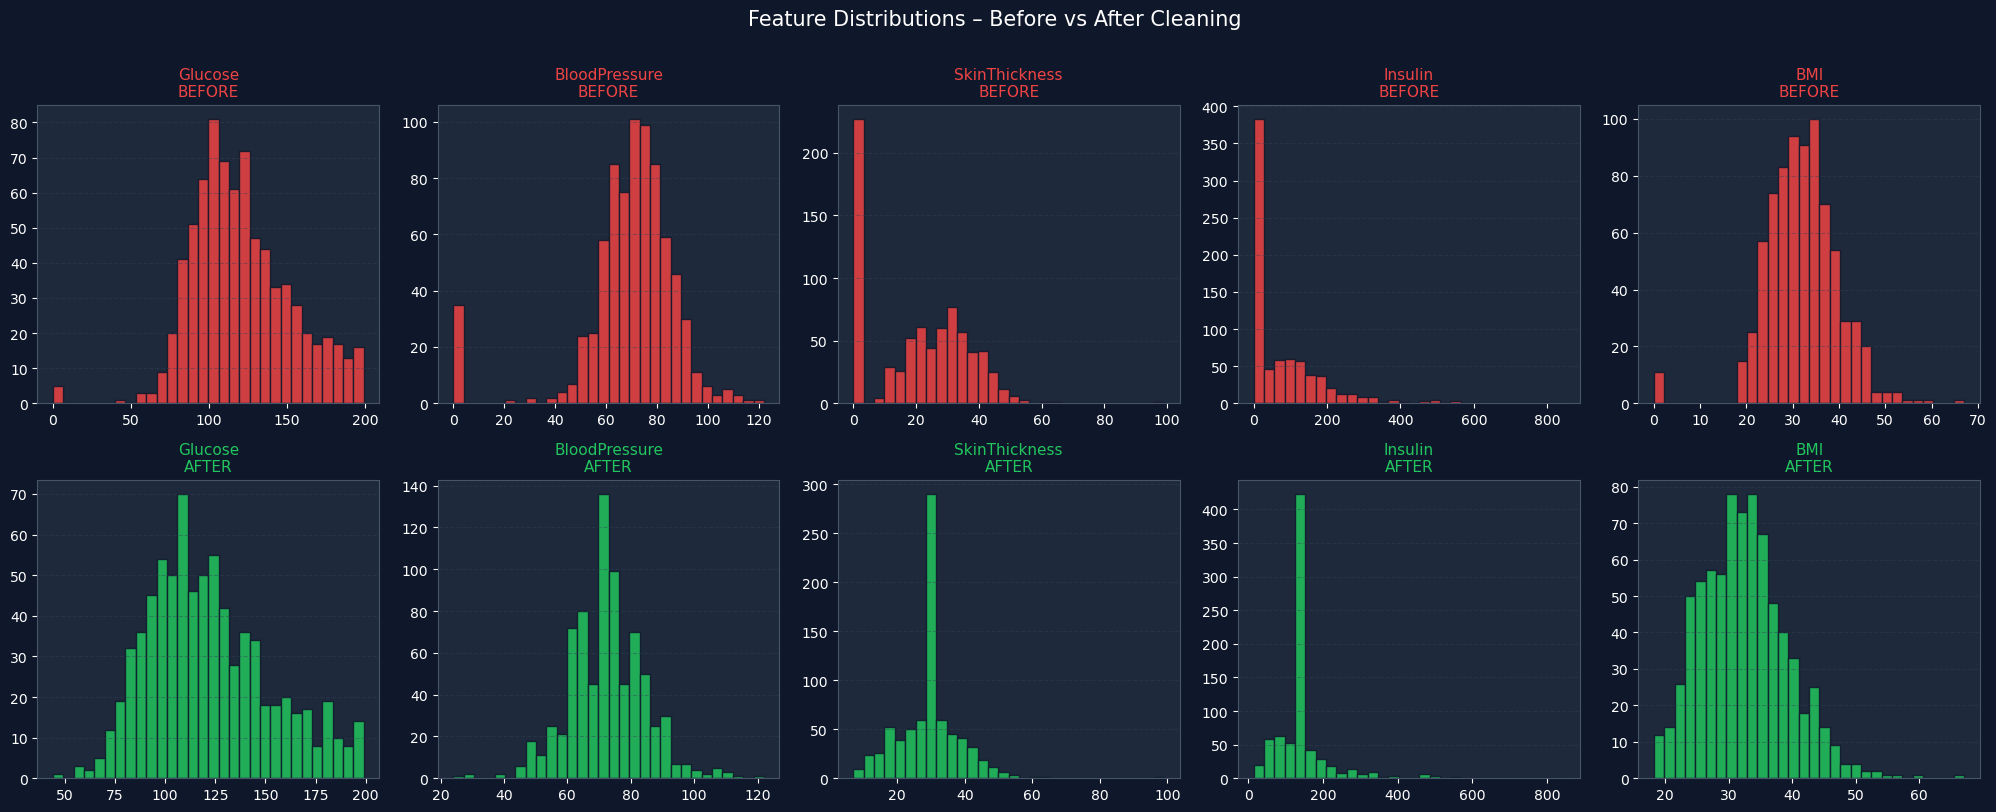

✅ Saved: fig1_distributions.png


In [13]:
# ── Fig 1: Feature Distribution Before vs After Cleaning ──────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Feature Distributions – Before vs After Cleaning', fontsize=15, y=1.01)

for i, col in enumerate(zero_cols):
    # Before
    axes[0, i].hist(df_raw[col], bins=30, color='#ef4444', edgecolor='#0f172a', alpha=0.85)
    axes[0, i].set_title(f'{col}\nBEFORE', color='#ef4444', fontsize=11)
    axes[0, i].grid(axis='y')
    # After
    axes[1, i].hist(df_clean[col], bins=30, color='#22c55e', edgecolor='#0f172a', alpha=0.85)
    axes[1, i].set_title(f'{col}\nAFTER', color='#22c55e', fontsize=11)
    axes[1, i].grid(axis='y')

plt.tight_layout()
plt.savefig('fig1_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: fig1_distributions.png")


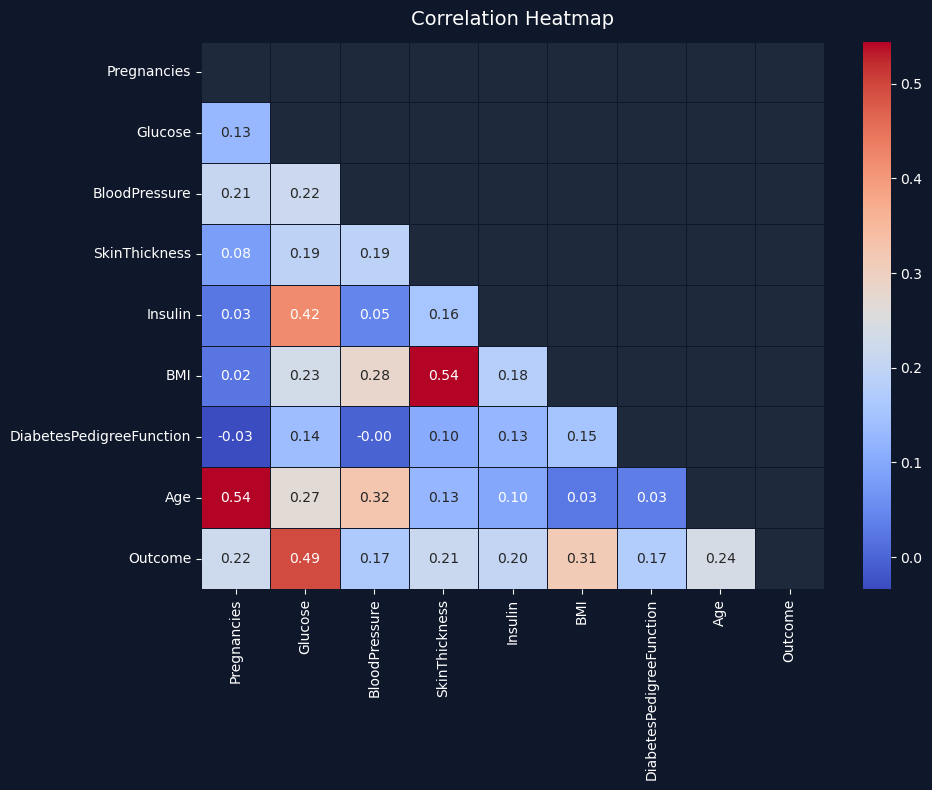

✅ Saved: fig2_correlation.png


In [14]:
# ── Fig 2: Correlation Heatmap ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, linecolor='#0f172a',
            annot_kws={'size': 10}, ax=ax, mask=mask)
ax.set_title('Correlation Heatmap', fontsize=14, pad=12)
plt.tight_layout()
plt.savefig('fig2_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: fig2_correlation.png")


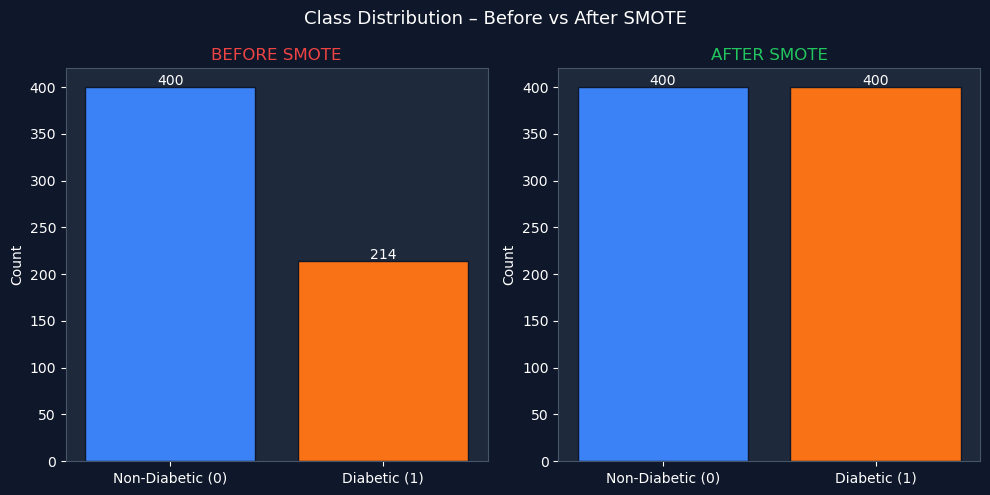

In [15]:
# ── Fig 3: Class Balance Before vs After SMOTE ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Class Distribution – Before vs After SMOTE', fontsize=13)

labels = ['Non-Diabetic (0)', 'Diabetic (1)']
colors = ['#3b82f6', '#f97316']

before = [( y_train_raw==0).sum(), (y_train_raw==1).sum()]
after  = [(y_train==0).sum(), (y_train==1).sum()]

axes[0].bar(labels, before, color=colors, edgecolor='#0f172a')
axes[0].set_title('BEFORE SMOTE', color='#ef4444', fontsize=12)
axes[0].set_ylabel('Count')
for i, v in enumerate(before):
    axes[0].text(i, v + 2, str(v), ha='center', color='white')

axes[1].bar(labels, after, color=colors, edgecolor='#0f172a')
axes[1].set_title('AFTER SMOTE', color='#22c55e', fontsize=12)
axes[1].set_ylabel('Count')
for i, v in enumerate(after):
    axes[1].text(i, v + 2, str(v), ha='center', color='white')

plt.tight_layout()
plt.savefig('fig3_smote.png', dpi=150, bbox_inches='tight')
plt.show()


## 🔵 Step 6 – K-Means Clustering + Elbow Method
> بنستخدم K-Means عشان نلاقي مراكز الـ RBF (Radial Basis Function centers)  
> الـ Elbow Method بتساعدنا نختار أحسن قيمة لـ K


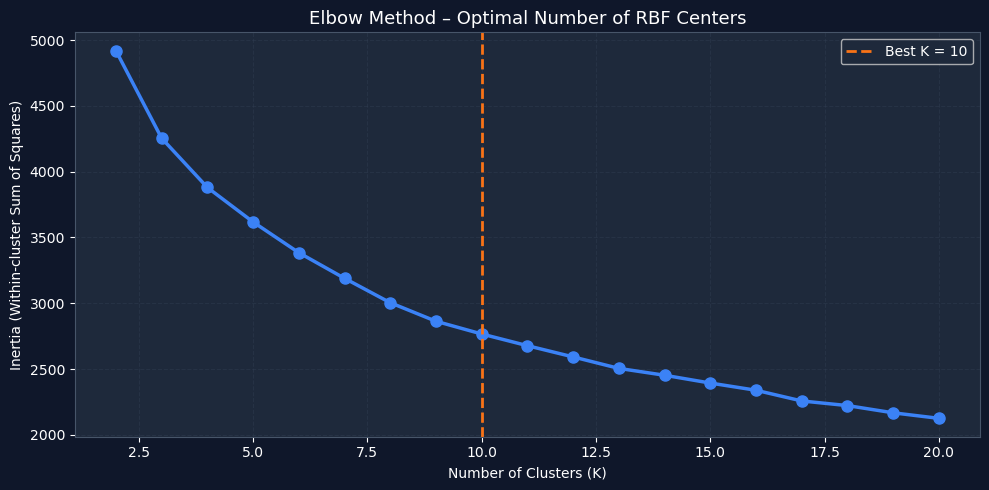

✅ Saved: fig4_elbow.png


In [16]:
# ── Elbow Method ──────────────────────────────────────────────────────────
inertias = []
K_range = range(2, 21)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train)
    inertias.append(km.inertia_)

# ── Fig 4: Elbow Curve ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(K_range, inertias, 'o-', color='#3b82f6', linewidth=2.5, markersize=8)
ax.axvline(x=10, color='#f97316', linestyle='--', linewidth=2, label='Best K = 10')
ax.set_title('Elbow Method – Optimal Number of RBF Centers', fontsize=13)
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia (Within-cluster Sum of Squares)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('fig4_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: fig4_elbow.png")


In [17]:
# ── Train Final K-Means with Best K ──────────────────────────────────────
BEST_K = 10

kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
kmeans.fit(X_train)

centers = kmeans.cluster_centers_   # shape: (K, n_features)
print(f"✅ K-Means trained with K = {BEST_K}")
print(f"   Centers shape: {centers.shape}")


✅ K-Means trained with K = 10
   Centers shape: (10, 8)


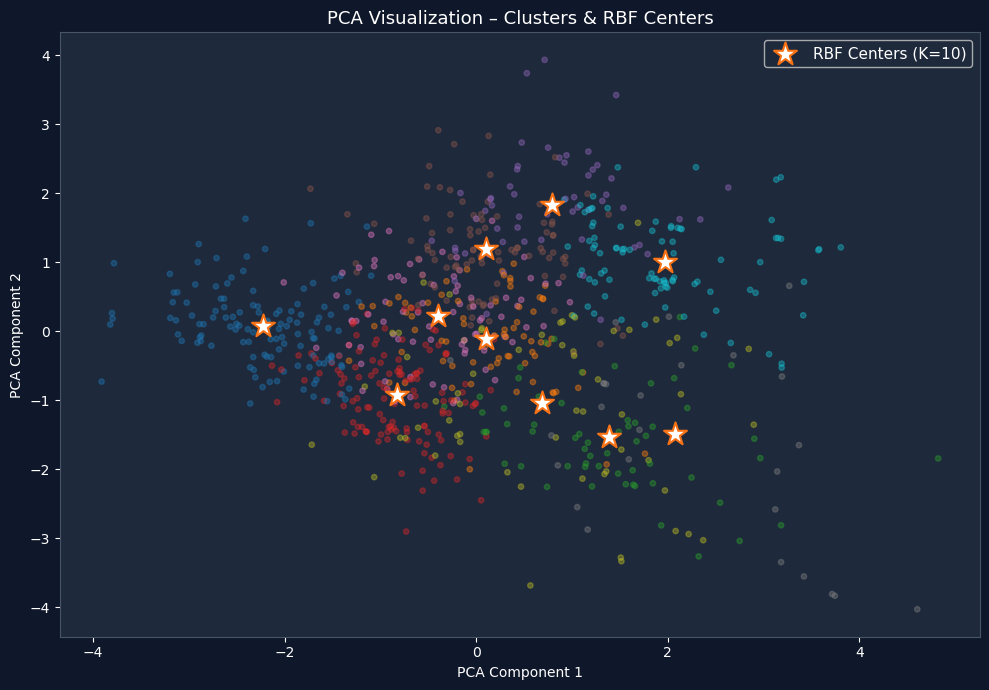

✅ Saved: fig5_pca_clusters.png


In [18]:
# ── Fig 5: PCA Visualization of Clusters + RBF Centers ────────────────────
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_train_pca    = pca.fit_transform(X_train)
centers_pca    = pca.transform(centers)

fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                     c=kmeans.labels_, cmap='tab10',
                     alpha=0.4, s=15)
ax.scatter(centers_pca[:, 0], centers_pca[:, 1],
           c='white', marker='*', s=300,
           edgecolors='#f97316', linewidths=1.5,
           zorder=5, label=f'RBF Centers (K={BEST_K})')

ax.set_title('PCA Visualization – Clusters & RBF Centers', fontsize=13)
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('fig5_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: fig5_pca_clusters.png")


## 🧠 Step 7 – RBF Neural Network (from Scratch)
> **Architecture:**
> - Input Layer → 8 features  
> - Hidden Layer → K RBF neurons (Gaussian activation)  
> - Output Layer → Logistic Regression
>
> **Gaussian RBF Formula:**  
> φ(x, cᵢ) = exp(−‖x − cᵢ‖² / (2σ²))


In [19]:
class RBFNetwork:
    """
    Radial Basis Function Neural Network – Built from Scratch
    ─────────────────────────────────────────────────────────
    Architecture:
      Input → RBF Hidden Layer (Gaussian) → Logistic Regression Output
    """

    def __init__(self, centers, sigma=1.0):
        self.centers = centers          # shape: (K, n_features)
        self.sigma   = sigma
        self.lr      = LogisticRegression(max_iter=1000, random_state=42)

    def _rbf_activation(self, X):
        """
        Compute Gaussian RBF for each sample and each center.
        Returns matrix of shape (n_samples, K)
        """
        activations = np.zeros((X.shape[0], self.centers.shape[0]))
        for i, center in enumerate(self.centers):
            diff = X - center                          # (n_samples, n_features)
            dist_sq = np.sum(diff ** 2, axis=1)        # (n_samples,)
            activations[:, i] = np.exp(-dist_sq / (2 * self.sigma ** 2))
        return activations

    def fit(self, X, y):
        """Train: compute RBF features → fit Logistic Regression"""
        H = self._rbf_activation(X)
        self.lr.fit(H, y)
        return self

    def predict_proba(self, X):
        """Return probabilities for both classes"""
        H = self._rbf_activation(X)
        return self.lr.predict_proba(H)

    def predict(self, X, threshold=0.5):
        """Predict class labels using given threshold"""
        proba = self.predict_proba(X)[:, 1]
        return (proba >= threshold).astype(int)


print("✅ RBFNetwork class defined")


✅ RBFNetwork class defined


In [20]:
# ── Compute Sigma (average distance between centers) ──────────────────────
dists = []
for i in range(len(centers)):
    for j in range(i+1, len(centers)):
        dists.append(np.linalg.norm(centers[i] - centers[j]))
sigma = np.mean(dists)
print(f"✅ Sigma computed = {sigma:.4f}")

# ── Train RBF Network ─────────────────────────────────────────────────────
rbf_net = RBFNetwork(centers=centers, sigma=sigma)
rbf_net.fit(X_train, y_train)
print("✅ RBF Network trained successfully")


✅ Sigma computed = 3.1981
✅ RBF Network trained successfully


## 📈 Step 8 – Accuracy vs Different K Values

  K =   3  →  Accuracy = 0.6948
  K =   5  →  Accuracy = 0.6948
  K =   8  →  Accuracy = 0.6883
  K =  10  →  Accuracy = 0.7078
  K =  12  →  Accuracy = 0.7078
  K =  15  →  Accuracy = 0.7078
  K =  20  →  Accuracy = 0.7143


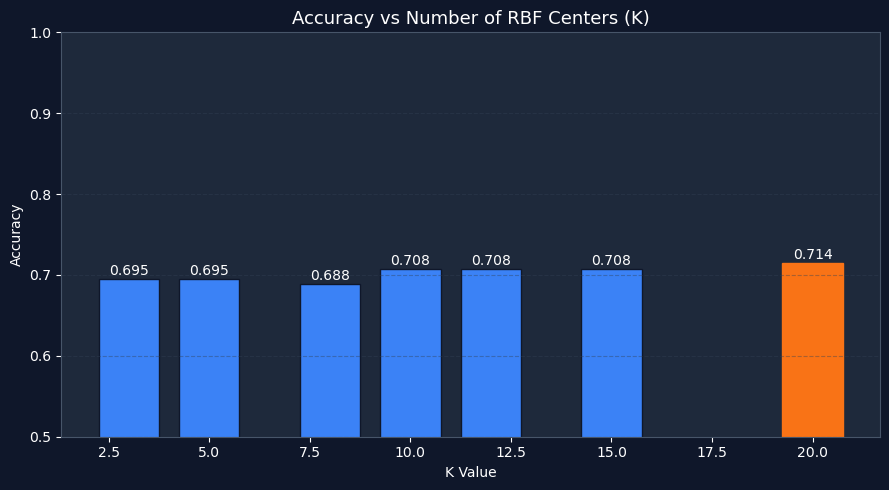

✅ Saved: fig6_k_accuracy.png


In [21]:
k_values  = [3, 5, 8, 10, 12, 15, 20]
k_acc     = []

for k in k_values:
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_temp.fit(X_train)
    c_temp = km_temp.cluster_centers_
    net_temp = RBFNetwork(centers=c_temp, sigma=sigma)
    net_temp.fit(X_train, y_train)
    preds = net_temp.predict(X_test)
    acc   = (preds == y_test).mean()
    k_acc.append(acc)
    print(f"  K = {k:3d}  →  Accuracy = {acc:.4f}")

# ── Fig 6: K vs Accuracy ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(k_values, k_acc, color='#3b82f6', edgecolor='#0f172a', width=1.5)
best_idx = np.argmax(k_acc)
bars[best_idx].set_color('#f97316')
ax.set_title('Accuracy vs Number of RBF Centers (K)', fontsize=13)
ax.set_xlabel('K Value')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.5, 1.0)
for bar, acc in zip(bars, k_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.3f}', ha='center', color='white', fontsize=10)
ax.grid(axis='y')
plt.tight_layout()
plt.savefig('fig6_k_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: fig6_k_accuracy.png")


## ⚙️ Step 9 – Threshold Optimization (F1-Score)
> Default threshold = 0.5 مش دايماً الأحسن.  
> بنجرب كل قيمة من 0.1 لـ 0.9 ونختار اللي يعطي أحسن F1-Score.


In [22]:
proba_test = rbf_net.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.91, 0.01)
f1_scores  = []

for t in thresholds:
    preds = (proba_test >= t).astype(int)
    f1 = f1_score(y_test, preds, zero_division=0)
    f1_scores.append(f1)

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1        = max(f1_scores)

print(f"✅ Best Threshold : {best_threshold:.2f}")
print(f"   Best F1-Score  : {best_f1:.4f}")


✅ Best Threshold : 0.40
   Best F1-Score  : 0.6619


## 📉 Step 10 – Model Evaluation

In [23]:
y_pred  = rbf_net.predict(X_test, threshold=best_threshold)
accuracy = (y_pred == y_test).mean()

print(f"📊 Final Results (threshold = {best_threshold:.2f}):")
print(f"   Accuracy : {accuracy:.4f}")
print(f"   F1-Score : {f1_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred,
      target_names=['Non-Diabetic', 'Diabetic']))


📊 Final Results (threshold = 0.40):
   Accuracy : 0.6948
   F1-Score : 0.6619

              precision    recall  f1-score   support

Non-Diabetic       0.88      0.61      0.72       100
    Diabetic       0.54      0.85      0.66        54

    accuracy                           0.69       154
   macro avg       0.71      0.73      0.69       154
weighted avg       0.76      0.69      0.70       154



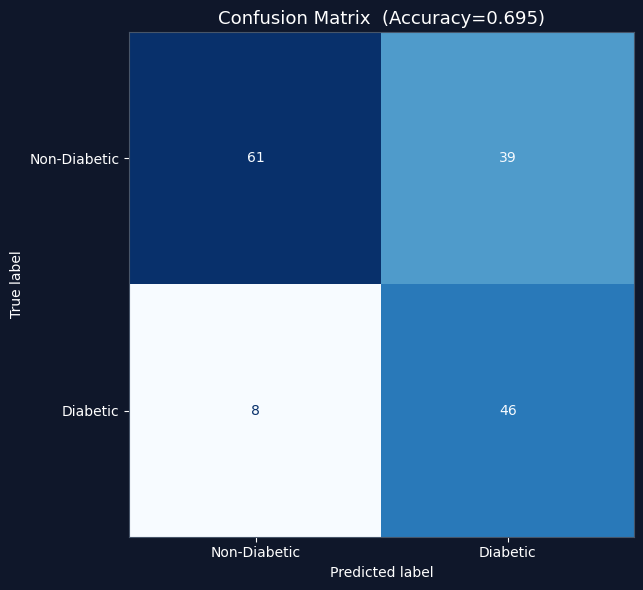

✅ Saved: fig7_confusion_matrix.png


In [24]:
# ── Fig 7: Confusion Matrix ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Non-Diabetic', 'Diabetic'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix  (Accuracy={accuracy:.3f})', fontsize=13)
plt.tight_layout()
plt.savefig('fig7_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: fig7_confusion_matrix.png")


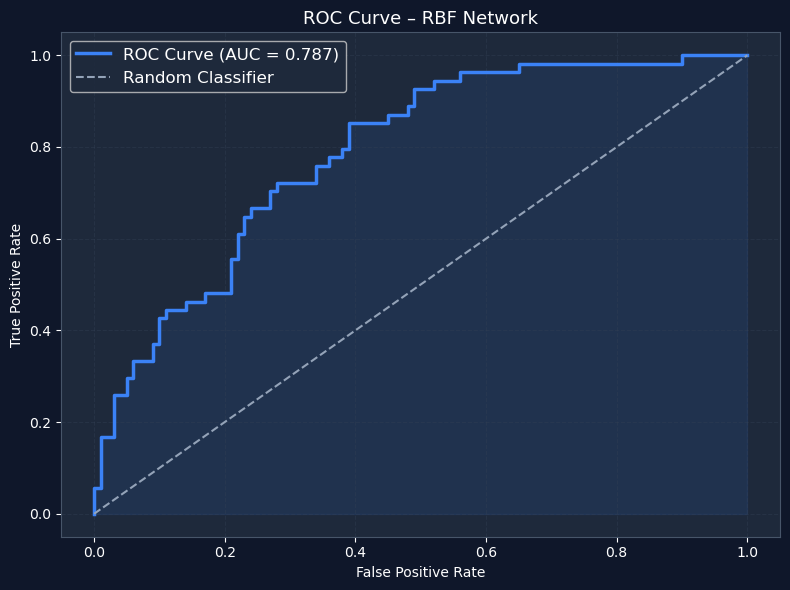

✅ Saved: fig8_roc_curve.png  |  AUC = 0.787


In [25]:
# ── Fig 8: ROC Curve ──────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, proba_test)
roc_auc      = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#3b82f6', lw=2.5,
        label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax.plot([0,1],[0,1], color='#94a3b8', linestyle='--', lw=1.5, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.1, color='#3b82f6')
ax.set_title('ROC Curve – RBF Network', fontsize=13)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=12)
ax.grid(True)
plt.tight_layout()
plt.savefig('fig8_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: fig8_roc_curve.png  |  AUC = {roc_auc:.3f}")


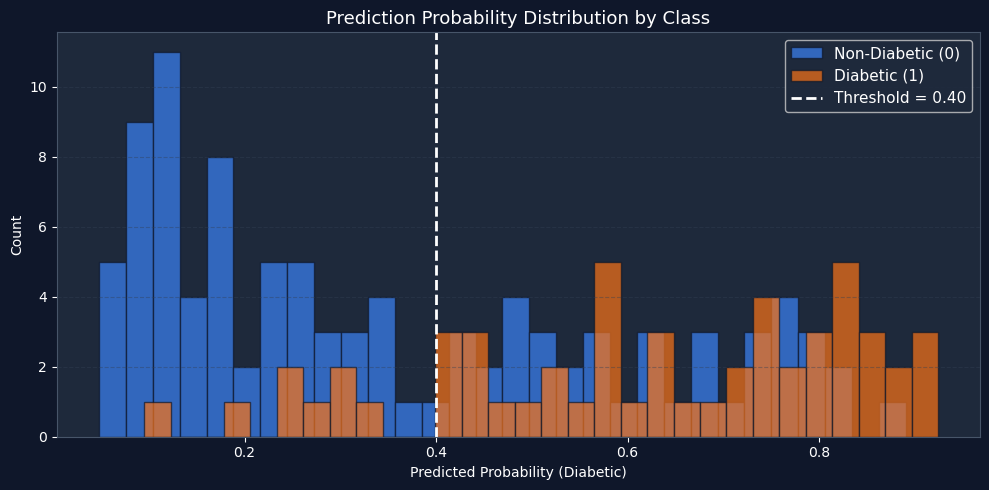

✅ Saved: fig9_prob_distribution.png


In [26]:
# ── Fig 9: Prediction Probability Distribution ────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

proba_class0 = proba_test[y_test == 0]
proba_class1 = proba_test[y_test == 1]

ax.hist(proba_class0, bins=30, color='#3b82f6', alpha=0.7,
        label='Non-Diabetic (0)', edgecolor='#0f172a')
ax.hist(proba_class1, bins=30, color='#f97316', alpha=0.7,
        label='Diabetic (1)',     edgecolor='#0f172a')
ax.axvline(best_threshold, color='white', linestyle='--',
           linewidth=2, label=f'Threshold = {best_threshold:.2f}')
ax.set_title('Prediction Probability Distribution by Class', fontsize=13)
ax.set_xlabel('Predicted Probability (Diabetic)')
ax.set_ylabel('Count')
ax.legend(fontsize=11)
ax.grid(axis='y')
plt.tight_layout()
plt.savefig('fig9_prob_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: fig9_prob_distribution.png")


## 🤖 Step 11 – GROQ AI Integration (LLaMA 3.3 70B)
> بنستخدم GROQ API عشان يولد تقرير طبي تفسيري لكل نتيجة تنبؤ  
> ⚠️ **مهم:** ضع الـ API Key الخاص بك في المتغير أدناه


In [27]:
# ⚠️ ضع GROQ API Key هنا
GROQ_API_KEY = "your_groq_api_key_here"

def generate_medical_report(pregnancies, glucose, blood_pressure,
                             skin_thickness, insulin, bmi, dpf, age,
                             prediction, probability):
    """
    توليد تقرير طبي تفسيري باستخدام GROQ LLaMA 3.3 70B
    """
    try:
        client = Groq(api_key=GROQ_API_KEY)

        risk_level = "HIGH RISK" if prediction == 1 else "LOW RISK"
        abnormal = []
        if glucose > 125:   abnormal.append(f"Glucose={glucose} (HIGH > 125)")
        if bmi > 30:        abnormal.append(f"BMI={bmi} (OBESE > 30)")
        if blood_pressure > 90: abnormal.append(f"BloodPressure={blood_pressure} (HIGH > 90)")
        if insulin > 200:   abnormal.append(f"Insulin={insulin} (HIGH > 200)")
        if age > 45:        abnormal.append(f"Age={age} (Risk factor > 45)")
        if dpf > 0.8:       abnormal.append(f"DiabetesPedigree={dpf} (HIGH > 0.8)")

        abnormal_str = ", ".join(abnormal) if abnormal else "None detected"

        prompt = f"""You are an expert medical AI assistant specializing in diabetes risk assessment.

Patient Data:
- Pregnancies: {pregnancies}
- Glucose: {glucose} mg/dL
- Blood Pressure: {blood_pressure} mmHg
- Skin Thickness: {skin_thickness} mm
- Insulin: {insulin} μU/mL
- BMI: {bmi}
- Diabetes Pedigree Function: {dpf}
- Age: {age} years

RBF Neural Network Prediction: {risk_level}
Diabetes Probability: {probability:.1%}
Abnormal Values: {abnormal_str}

Please provide a comprehensive medical report including:
1. 🔍 RISK ASSESSMENT: Overall risk level and key factors
2. ⚠️  ABNORMAL VALUES: Analysis of concerning measurements
3. 💡 REASONING: Why the model predicted this outcome
4. ✅ HEALTH RECOMMENDATIONS: Specific actionable advice
5. 🏥 NEXT STEPS: Recommended medical actions

Write in a clear, professional but patient-friendly tone. Be specific and empathetic.
Keep the report under 400 words."""

        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[{"role": "user", "content": prompt}],
            max_tokens=600,
            temperature=0.3
        )

        return response.choices[0].message.content

    except Exception as e:
        return f"⚠️ GROQ API Error: {str(e)}\nPlease check your API key."


print("✅ GROQ medical report function defined")


✅ GROQ medical report function defined


## 🌐 Step 12 – Gradio Web Interface

In [28]:
def predict_diabetes(pregnancies, glucose, blood_pressure,
                     skin_thickness, insulin, bmi, dpf, age):
    """
    Main prediction function called by Gradio
    """
    # ── Prepare input ────────────────────────────────────────────────────
    input_data = np.array([[pregnancies, glucose, blood_pressure,
                            skin_thickness, insulin, bmi, dpf, age]])
    input_scaled = scaler.transform(input_data)

    # ── Predict ──────────────────────────────────────────────────────────
    proba       = rbf_net.predict_proba(input_scaled)[0]
    proba_diab  = proba[1]
    proba_no    = proba[0]
    prediction  = int(proba_diab >= best_threshold)

    # ── Result label ─────────────────────────────────────────────────────
    if prediction == 1:
        result = f"⚠️ HIGH RISK – Diabetic ({proba_diab:.1%} probability)"
    else:
        result = f"✅ LOW RISK – Non-Diabetic ({proba_no:.1%} probability)"

    # ── AI Medical Report ─────────────────────────────────────────────────
    report = generate_medical_report(
        pregnancies, glucose, blood_pressure,
        skin_thickness, insulin, bmi, dpf, age,
        prediction, proba_diab
    )

    return (
        result,
        f"{proba_diab:.1%}",
        f"{proba_no:.1%}",
        report
    )


# ── Build Gradio UI ───────────────────────────────────────────────────────
with gr.Blocks(
    theme=gr.themes.Base(
        primary_hue="blue",
        secondary_hue="orange",
        neutral_hue="slate"
    ),
    title="🩺 Diabetes Risk Prediction"
) as demo:

    gr.Markdown("""
    # 🩺 Diabetes Risk Prediction System
    ### RBF Neural Network + GROQ AI Medical Report
    ---
    Enter patient medical data below and click **Predict** to get a full risk assessment.
    """)

    with gr.Row():
        with gr.Column():
            gr.Markdown("### 📋 Patient Medical Data")
            pregnancies   = gr.Slider(0, 17,  value=3,   step=1,    label="Pregnancies")
            glucose       = gr.Slider(0, 200, value=117, step=1,    label="Glucose (mg/dL)")
            blood_pressure= gr.Slider(0, 122, value=72,  step=1,    label="Blood Pressure (mmHg)")
            skin_thickness= gr.Slider(0, 99,  value=23,  step=1,    label="Skin Thickness (mm)")
            insulin       = gr.Slider(0, 846, value=30,  step=1,    label="Insulin (μU/mL)")
            bmi           = gr.Slider(0, 67,  value=32,  step=0.1,  label="BMI")
            dpf           = gr.Slider(0.0, 2.5, value=0.47, step=0.01, label="Diabetes Pedigree Function")
            age           = gr.Slider(21, 81, value=33,  step=1,    label="Age (years)")
            predict_btn   = gr.Button("🔍 Predict", variant="primary", size="lg")

        with gr.Column():
            gr.Markdown("### 📊 Prediction Results")
            result_label   = gr.Textbox(label="🎯 Prediction", lines=2)
            proba_diab_box = gr.Textbox(label="🔴 Diabetes Probability")
            proba_no_box   = gr.Textbox(label="🟢 No Diabetes Probability")

            gr.Markdown("### 🤖 AI Medical Report (GROQ LLaMA 3.3)")
            report_box = gr.Textbox(label="Medical Report", lines=18)

    predict_btn.click(
        fn=predict_diabetes,
        inputs=[pregnancies, glucose, blood_pressure, skin_thickness,
                insulin, bmi, dpf, age],
        outputs=[result_label, proba_diab_box, proba_no_box, report_box]
    )

    gr.Markdown("""
    ---
    > **Model:** RBF Neural Network (K=10 centers, manually implemented)  
    > **Dataset:** Pima Indians Diabetes Dataset (768 records)  
    > **AI:** GROQ API – LLaMA 3.3 70B Versatile
    """)

print("✅ Gradio interface built")


✅ Gradio interface built


In [29]:
# ── Launch App ───────────────────────────────────────────────────────────
# share=True يولد رابط عام تقدر تشاركه
demo.launch(share=True, debug=False)


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://53fa4bfb2262bfb272.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
